# Run The Training Pipeline

This notebook runs the standard PioneerML `training_pipeline` with the sensor-health tutorial config. The run is intentionally tiny: one HPO trial, one short training pass, evaluation, and export.

A ZenML pipeline call returns a large `PipelineRunResponse`. We assign it to `training_run` and print only the run name/status so the notebook stays readable.

> **Notebook memory:** Importing the scientific Python stack (for example PyTorch, NumPy, Matplotlib, and ZenML) can keep approximately 1 GiB of RAM assigned to this kernel for its lifetime. Python cannot safely unload native extension modules. **After finishing this tutorial, restart its kernel to clear imported libraries and release that RAM** (or shut down the kernel entirely). Restarting keeps the notebook open with a fresh, low-memory kernel. Do this before running several tutorial notebooks at once.

In [1]:
from pathlib import Path
import sys
from tempfile import mkdtemp

# Source-checkout bootstrap: this lets the notebook import PioneerML and the
# base plugin before either package has been installed in editable mode.
for root in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    for src in (root / "src", root / "plugins" / "example_plugin" / "src"):
        if (src / "pioneerml").exists() or (src / "pioneerml_example_plugin").exists():
            src_text = str(src)
            if src_text not in sys.path:
                sys.path.insert(0, src_text)

from IPython.display import Image, display

from pioneerml.evaluation.plots.loss import LossCurvesPlot
from pioneerml.integration.zenml import load_step_output
from pioneerml.integration.zenml import utils as zenml_utils

import pioneerml_example_plugin.components_tutorial_examples  # registers tutorial components
from pioneerml_example_plugin.components_tutorial_examples.pipeline import (
    load_config,
    training_pipeline,
    with_output_root,
)

PROJECT_ROOT = zenml_utils.find_project_root()
zenml_utils.setup_zenml_for_notebook(root_path=PROJECT_ROOT, use_in_memory=True)
full_config = load_config()


Using ZenML repository root: /workspace
Ensure this is the top-level of your repo (.zen must live here).


## Launch Training

`with_output_root` keeps generated plots and exported models outside the plugin source tree. The config itself is still the checked-in tutorial config; only output paths are redirected for this run.

Initiating a new run for the pipeline: training_pipeline.
Caching is disabled by default for training_pipeline.
Using user: default
Using stack: default
  deployer: default
  artifact_store: default
  orchestrator: default
You can visualize your pipeline runs in the ZenML Dashboard. In order to try it locally, please run zenml login --local.
Step tune_model has started.


[I 2026-07-11 07:40:28,191] Using an existing study with name 'sensor_health_tutorial_bce' instead of creating a new one.


[tune_model] GPU available: True (cuda), used: False
[tune_model] TPU available: False, using: 0 TPU cores
[tune_model] /opt/conda/envs/pioneerml/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing Trainer(accelerator='gpu').



Output()

[tune_model] Trainer.fit stopped: max_epochs=25 reached.


[I 2026-07-11 07:40:33,055] Trial 4 finished with value: 0.04286370798945427 and parameters: {'hidden': 32, 'lr': 0.01086664154042655, 'batch_size_exp': 7}. Best is trial 2 with value: 0.042506683617830276.


Step tune_model has finished in 5.098s.
Step train_model has started.
[train_model] GPU available: True (cuda), used: False
[train_model] TPU available: False, using: 0 TPU cores
[train_model] /opt/conda/envs/pioneerml/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing Trainer(accelerator='gpu').



Output()

[train_model] Trainer.fit stopped: max_epochs=25 reached.


Step train_model has finished in 6.080s.
Step evaluate_model has started.
Step evaluate_model has finished in 0.357s.
Step export_model has started.
Step export_model has finished in 0.630s.
Pipeline run has finished in 13.519s.
Training pipeline completed: training_pipeline-2026_07_11-07_40_27_642523
Status: completed
Notebook output root: /tmp/pioneerml-components-training-clr9brg1
Metrics: {'loss': 0.04787191364375611, 'num_eval_samples': 155, 'sensor_accuracy': 0.9741935729980469, 'sensor_precision': 0.948051948051948, 'sensor_recall': 1.0, 'sensor_health_score_histogram_path': '/tmp/pioneerml-components-training-clr9brg1/sensor_score_histogram.png', 'score_histogram_path': '/tmp/pioneerml-components-training-clr9brg1/sensor_score_histogram.png'}
Export: None
Loss points: train=16, val=0


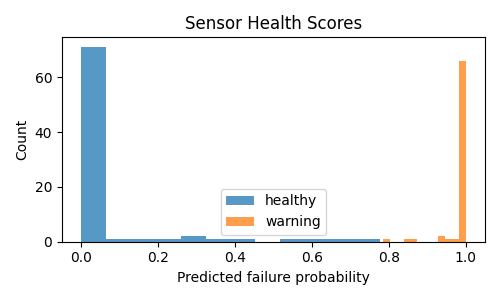

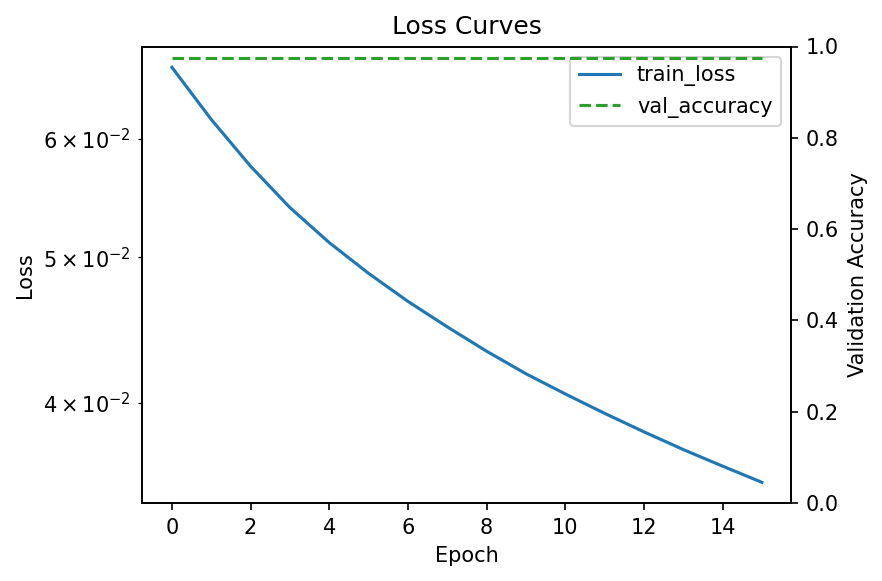

In [2]:
run_root = Path(mkdtemp(prefix="pioneerml-components-training-"))
training_config = with_output_root(full_config["training"], run_root)

training_run = training_pipeline.with_options(enable_cache=False)(
    pipeline_config=training_config,
)

print(f"Training pipeline completed: {training_run.name}")
print(f"Status: {training_run.status}")
print(f"Notebook output root: {run_root}")

train_output = load_step_output(training_run, "train_model")
evaluate_output = load_step_output(training_run, "evaluate_model")
export_output = load_step_output(training_run, "export_model")

trained_module = train_output.get("module") if isinstance(train_output, dict) else train_output
metrics = evaluate_output.get("metrics") if isinstance(evaluate_output, dict) else evaluate_output
exported = export_output.get("exported") if isinstance(export_output, dict) else export_output

summary_metrics = dict(metrics or {})
summary_metrics.pop("train_loss_history", None)
summary_metrics.pop("val_loss_history", None)

print("Metrics:", summary_metrics)
print("Export:", exported)

score_plot_path = run_root / "sensor_score_histogram.png"
loss_plot_path = run_root / "sensor_loss_curves.png"

if trained_module is None:
    raise RuntimeError("The train_model step did not return a trained module artifact.")

train_losses = list(
    getattr(trained_module, "train_epoch_loss_history", None)
    or getattr(trained_module, "train_loss_history", None)
    or []
)
val_losses = list(
    getattr(trained_module, "val_epoch_loss_history", None)
    or getattr(trained_module, "val_loss_history", None)
    or []
)
print(f"Loss points: train={len(train_losses)}, val={len(val_losses)}")

LossCurvesPlot().render(
    train_losses,
    val_losses=val_losses,
    val_accuracy=(summary_metrics.get("sensor_accuracy") if isinstance(summary_metrics, dict) else None),
    save_path=str(loss_plot_path),
    show=False,
)

display(Image(filename=str(score_plot_path)))
display(Image(filename=str(loss_plot_path)))


## What To Notice

The registered evaluator produced `sensor_score_histogram.png` from the `sensor_health_score_histogram` plot plugin. The loss curves use PioneerML's registered `loss_curves` plot and the trained module artifact loaded from the `train_model` step.

The pipeline response object is still available as `training_run`, but the notebook never displays it directly.